# ZOD LiDAR Exploration (for pedestrian detection)

In [2]:
# Core imports for data loading + plotting.
from __future__ import annotations

import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# Consistent plotting defaults make visual comparisons easier across cells.
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["image.cmap"] = "viridis"

# Dataset root for original ZOD single-frame data.
ORIGINAL_ZOD_ROOT = Path("/home/edgelab/zod_dino_data/train2017")
FRAME_DIR_000000 = ORIGINAL_ZOD_ROOT / "000000"

# Frame selection is discovered dynamically from available data.
print(f"ORIGINAL_ZOD_ROOT exists: {ORIGINAL_ZOD_ROOT.exists()}")
print(f"ORIGINAL_ZOD_ROOT: {ORIGINAL_ZOD_ROOT}")

ORIGINAL_ZOD_ROOT exists: True
ORIGINAL_ZOD_ROOT: /home/edgelab/zod_dino_data/train2017


## Nearest-sweep helpers

The helper function "nearest_lidar_filename" returns the LiDAR `.npy` filename with timestamp closest to `keyframe_time` in `info.json`. "average_nearest_lidar_offset_ms" reports the average absolute offset over 500 keyframes.


## 1) Keyframes have:

- `lidar_velodyne/*.npy`
- `annotations/object_detection.json`
- camera metadata in `info.json`
- calibration.json
- info.json
- metadata.json 


### Note from ZOD docs

ZOD says annotations are for the camera-LiDAR keyframe pair, not all surrounding sweeps.

- one camera keyframe timestamp
- several LiDAR sweeps around that time
- labels aligned to keyframe context

In [3]:
def _read_json(path: Path):
    # Tiny helper so I don't repeat try/except in every cell.
    try:
        return json.loads(path.read_text())
    except Exception as e:
        print(f"Could not read JSON: {path}\n{e}")
        return None


def _iso_to_dt(s: str) -> datetime:
    # Z-suffixed timestamp helper.
    # iso format: 2021-01-01T00:00:00.000000Z
    # datetime format: 2021-01-01 00:00:00+00:00
    return datetime.fromisoformat(s.replace("Z", "+00:00"))


def _list_npy_files(lidar_dir: Path) -> list[Path]:
    # Sort by filename so timestamps appear in order.
    return sorted([p for p in lidar_dir.glob("*.npy")])


def find_keyframe_timestamp(frame_dir: Path, info_dict: dict) -> datetime:
    """
    Find the keyframe timestamp from the info.json file.
    """
    return _iso_to_dt(info_dict["keyframe_time"])



In [4]:
def nearest_lidar_filename(frame_dir: Path) -> str | None:
    """
    Input: Keyframe Directory Path Object
    Output: LiDAR Filename (lidar_velodyne) with timestamp closest to keyframe_time
    We read the info.json file to get the keyframe_time. 
    Instead of using the full LiDAR window ~ 11-12 .npy files, we just use the closest one. 
    """
    info = _read_json(frame_dir / "info.json")
    lidar_dir = frame_dir / "lidar_velodyne"

    if not isinstance(info, dict) or "keyframe_time" not in info or not lidar_dir.exists():
        return None

    keyframe_timestamp = _iso_to_dt(info["keyframe_time"])
    best_name = None
    # initialize best absolute delta time to infinity
    best_abs_dt = float("inf")

    for p in lidar_dir.glob("*.npy"):
        # Filename pattern: <frame_id>_<car>_<ISO8601>.npy
        timestamp_str = p.stem.rsplit("_", 1)[-1]
        try:
            delta_time_s = (_iso_to_dt(timestamp_str) - keyframe_timestamp).total_seconds()
        except Exception:
            continue

        abs_dt = abs(delta_time_s)
        if abs_dt < best_abs_dt:
            best_abs_dt = abs_dt
            best_name = p.name

    return best_name


def average_nearest_lidar_offset_ms(root: Path, n_keyframes: int = 1000) -> float:
    """Average absolute keyframe-to-nearest-lidar time gap (milliseconds)."""
    frame_dirs = [p for p in root.iterdir() if p.is_dir()][:n_keyframes]
    offsets_ms: list[float] = []

    for fd in frame_dirs:
        info = _read_json(fd / "info.json")
        if not isinstance(info, dict) or "keyframe_time" not in info:
            continue

        nearest_name = nearest_lidar_filename(fd)
        if nearest_name is None:
            continue

        key_t = _iso_to_dt(info["keyframe_time"])
        lidar_t = _iso_to_dt(Path(nearest_name).stem.rsplit("_", 1)[-1])
        offsets_ms.append(abs((lidar_t - key_t).total_seconds()) * 1000.0)

    return float(np.mean(offsets_ms)) if offsets_ms else float("nan")


# Example usage.
nearest_name_example = nearest_lidar_filename(FRAME_DIR_000000)
print(f"Keyframe timestamp: {find_keyframe_timestamp(FRAME_DIR_000000, _read_json(FRAME_DIR_000000 / 'info.json'))}")
print("Nearest LiDAR filename for FRAME_DIR:", nearest_name_example)

avg_offset_ms_500 = average_nearest_lidar_offset_ms(ORIGINAL_ZOD_ROOT, n_keyframes=1000)
print(f"Average |nearest LiDAR - keyframe| over 1000 keyframes: {avg_offset_ms_500:.3f} ms")

Keyframe timestamp: 2021-04-19 10:23:10.444124+00:00
Nearest LiDAR filename for FRAME_DIR: 000000_india_2021-04-19T10:23:10.416676Z.npy
Average |nearest LiDAR - keyframe| over 1000 keyframes: 27.319 ms


We have a function that importantly extracts the nearest numpy file. 

- So one option is to just use this as our pointcloud. 

- 2nd option is to do multi-sweep (multiple .npy files over a certain time range like +- 0.2 seconds, and then deskew each points to a common time to account for motion) --> get a more dense and accurate point cloud. Issue with this approach is that there would be a mismatch between camera and lidar data since we'd be introducing a temporal element to lidar point cloud. So we will avoid this. 

- 3rd option: With single-sweep, every method sees the same “instantaneous” geometry. And within that single sweep we can deskew points to a common time to account for motion. 

In [5]:
# First valid candidate for reproducible exploration.
FRAME_DIR = FRAME_DIR_000000
print(f"Using FRAME_DIR: {FRAME_DIR}")

INFO_PATH = FRAME_DIR / "info.json"
META_PATH = FRAME_DIR / "metadata.json"
CALIB_PATH = FRAME_DIR / "calibration.json"
EGO_PATH = FRAME_DIR / "ego_motion.json"
OD_PATH = FRAME_DIR / "annotations" / "object_detection.json"
LIDAR_DIR = FRAME_DIR / "lidar_velodyne"

info = _read_json(INFO_PATH)
meta = _read_json(META_PATH)
calib = _read_json(CALIB_PATH)
ego_motion = _read_json(EGO_PATH)
od = _read_json(OD_PATH)

print("Loaded JSON assets:")
for p in [INFO_PATH, META_PATH, CALIB_PATH, EGO_PATH, OD_PATH]:
    print(f"- {p.name}: {'OK' if p.exists() else 'MISSING'}")

print(f"\nNum object annotations: {len(od) if isinstance(od, list) else 'N/A'}")
print(f"Frame metadata says num_pedestrians: {meta.get('num_pedestrians') if isinstance(meta, dict) else 'N/A'}")

Using FRAME_DIR: /home/edgelab/zod_dino_data/train2017/000000
Loaded JSON assets:
- info.json: OK
- metadata.json: OK
- calibration.json: OK
- ego_motion.json: OK
- object_detection.json: OK

Num object annotations: 281
Frame metadata says num_pedestrians: 40


In [6]:
# frame 000000 lidar path
closest_lidar_filename = nearest_lidar_filename(FRAME_DIR_000000)
closest_lidar_path = FRAME_DIR_000000 / "lidar_velodyne" / closest_lidar_filename


In [7]:
# Compare what info.json expects vs what is physically present in this local copy.
lidar_manifest = info.get("lidar_frames", {}).get("velodyne", []) if isinstance(info, dict) else []
expected_paths = [Path(x["filepath"]).name for x in lidar_manifest]
present_paths = [p.name for p in _list_npy_files(LIDAR_DIR)]

expected_set = set(expected_paths)
present_set = set(present_paths)

missing_local = sorted(expected_set - present_set)
extra_local = sorted(present_set - expected_set)

print(f"Expected sweeps from info.json: {len(expected_paths)}")
print(f"Present sweeps on disk:         {len(present_paths)}")
print(f"Missing locally:                {len(missing_local)}")
print(f"Extra locally:                  {len(extra_local)}")

if missing_local:
    print("\nFirst 5 missing sweeps (this often means partial download/subset):")
    for name in missing_local[:5]:
        print("-", name)

# Find the LiDAR sweep closest to the camera keyframe time.
keyframe_time = _iso_to_dt(info["keyframe_time"])
present_times = []
for p in _list_npy_files(LIDAR_DIR):
    # filename pattern: <frameid>_<car>_<iso>.npy
    iso = p.stem.split("_")[-1]
    present_times.append((p, _iso_to_dt(iso)))

closestlidar_path, closest_lidar_time = min(
    present_times,
    key=lambda t: abs((t[1] - keyframe_time).total_seconds()),
)

print(f"\nCamera keyframe_time: {keyframe_time.isoformat()}")
print(f"Closest LiDAR sweep:  {closestlidar_path.name}")
print(f"Time delta (s):       {(closest_lidar_time - keyframe_time).total_seconds():.6f}")

Expected sweeps from info.json: 21
Present sweeps on disk:         11
Missing locally:                10
Extra locally:                  0

First 5 missing sweeps (this often means partial download/subset):
- 000000_india_2021-04-19T10:23:09.306996Z.npy
- 000000_india_2021-04-19T10:23:09.417964Z.npy
- 000000_india_2021-04-19T10:23:09.972804Z.npy
- 000000_india_2021-04-19T10:23:10.083772Z.npy
- 000000_india_2021-04-19T10:23:10.194740Z.npy

Camera keyframe_time: 2021-04-19T10:23:10.444124+00:00
Closest LiDAR sweep:  000000_india_2021-04-19T10:23:10.416676Z.npy
Time delta (s):       -0.027448


## 3) What is inside one LiDAR `.npy`?

Each `.npy` is a structured point cloud array (not an image).

Fields in each .npy:
- `x`, `y`, `z` (point coordinates)
- `intensity` (return intensity)
- `diode_index` (laser ring index)
- `timestamp` (per-point timing within the sweep)

In [8]:
# Load the sweep closest to keyframe.
pts = np.load(closest_lidar_path)
#np to df
pts_df = pd.DataFrame(pts)

pts_df.head()

,timestamp,x,y,z,intensity,diode_index
0,-57567,8.279048,-0.003468,-1.720839,10,1
1,-57564,12.757461,-0.007570,-1.453529,65,9
2,-57562,17.248777,-0.013246,-1.163807,8,17
3,-57559,19.721287,-0.018587,-1.026646,16,25
4,-57556,19.671652,-0.008240,-0.116735,20,33


- per-point timestamp: microseconds (10^-6 sec) and relative to keyframe timestamp in UTC. 
- 3d coordinates are in meters. 
- Intensity is a measure of the reflection magnitude ranging from 0 to 255.
- diode_index -- which lidar lazer created the point. 

### WE visualize the "closest lidar path" in BEV view using some helper functions:

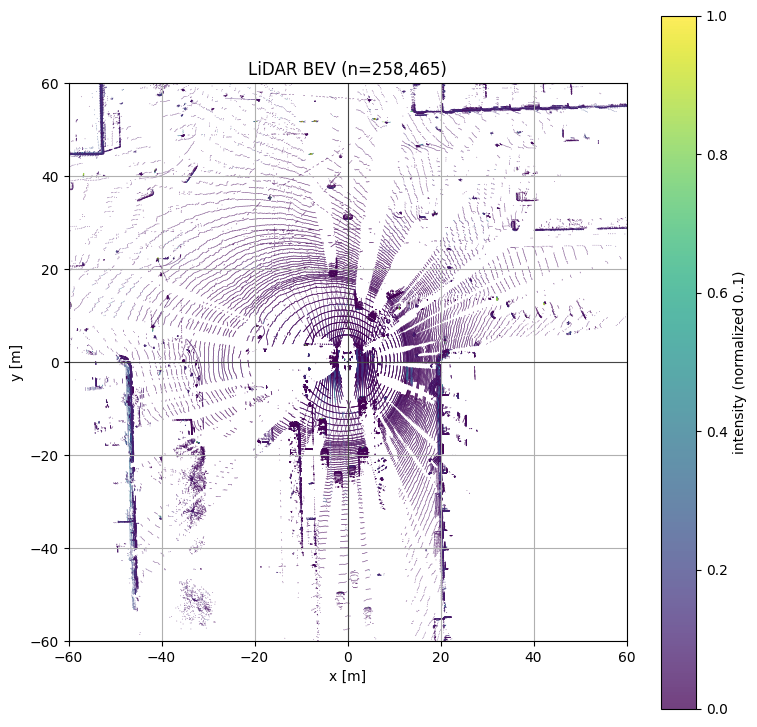

In [9]:
def _xyz_intensity_from_pts(pts: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Extract xyz (N,3) and intensity (N,) from structured or plain arrays."""
    if not isinstance(pts, np.ndarray):
        raise TypeError("pts must be a numpy ndarray")

    # Structured array path (expected for ZOD LiDAR .npy)
    if pts.dtype.names is not None:
        names = set(pts.dtype.names)
        required = {"x", "y", "z", "intensity"}
        if not required.issubset(names):
            raise ValueError(f"Structured pts is missing required fields: {required - names}")

        xyz = np.stack(
            [
                pts["x"].astype(np.float32),
                pts["y"].astype(np.float32),
                pts["z"].astype(np.float32),
            ],
            axis=1,
        )
        intensity = pts["intensity"].astype(np.float32)
        return xyz, intensity

    # Plain array fallback: [timestamp, x, y, z, intensity, ...]
    arr = np.asarray(pts)
    if arr.ndim != 2 or arr.shape[1] < 5:
        raise ValueError("Plain pts array must have shape (N, >=5): [timestamp, x, y, z, intensity, ...]")

    xyz = arr[:, 1:4].astype(np.float32)
    intensity = arr[:, 4].astype(np.float32)
    return xyz, intensity


def plot_lidar_bev(
    pts: np.ndarray,
    max_points: int = 200_000,
    seed: int = 0,
    point_size: float = 0.3,
    alpha: float = 0.75,
    cmap: str = "viridis",
    xlim: tuple[float, float] | None = None,
    ylim: tuple[float, float] | None = None,
) -> None:
    """
    input: .npy LidarVelodyne file
    BEV (x-y) scatter colored by intensity (0..255).
    input: structured or plain numpy array
    output: matplotlib figure
    """
    xyz, intensity = _xyz_intensity_from_pts(pts)

    # No downsampling: use all points.
    xyz_s = xyz
    inten_s = np.clip(intensity, 0.0, 255.0) / 255.0

    plt.figure(figsize=(9, 9))
    sc = plt.scatter(
        xyz_s[:, 0], xyz_s[:, 1],
        c=inten_s,
        s=point_size,
        alpha=alpha,
        cmap=cmap,
        linewidths=0,
    )

    plt.axhline(0.0, linewidth=0.8, color="black", alpha=0.6)
    plt.axvline(0.0, linewidth=0.8, color="black", alpha=0.6)
    plt.gca().set_aspect("equal", adjustable="box")

    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)

    plt.title(f"LiDAR BEV (n={len(xyz_s):,})")
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    cbar = plt.colorbar(sc)
    cbar.set_label("intensity (normalized 0..1)")
    plt.show()


# Example calls:
plot_lidar_bev(pts, xlim=(-60, 60), ylim=(-60, 60))

In [10]:
ts = pts_df["timestamp"]
print(f"Total microseconds in the sweep: {abs(ts.max()) + abs(ts.min())}")
print(f"Total seconds in the sweep: {(abs(ts.max()) + abs(ts.min()))/1e6}")

Total microseconds in the sweep: 115033
Total seconds in the sweep: 0.115033


Since each point has a different timestamp, we have a mismatch. All camera pixels are captured instantaneously whereas LiDAR point map was created over time as the car was moving. We can reduce this noise by "deskewing" the LiDAR point map within the .npy that is closest to the camera timestamp and adjust for this motion. We can do this using the data in oxts.hdf5. 


INSPECTING oxts.hdf5 (The vehicle motion log during that 2-second window.). It contains:

- timestamp ← when measurement was taken
- poses ← vehicle pose at each timestamp
- velocities
- accelerations
- angular rates
- GPS coordinates

#NOTE: HDF5 file (an object in itself) can be thought of as a container (or group) that holds a variety of heterogeneous data objects (or datasets). The datasets can be images, tables, graphs, and even documents

In [11]:
import h5py

path = FRAME_DIR / "oxts.hdf5"
with h5py.File(path, "r") as f:
    #top-level dataset names (like “files at the root”)
    print("keys:", list(f.keys()))
    # also list nested keys if needed
    for k in f.keys():
        obj = f[k]
        if hasattr(obj, "keys"):
            print(k, "subkeys:", list(obj.keys())[:20])

keys: ['accelerationX', 'accelerationY', 'accelerationZ', 'angularRateX', 'angularRateY', 'angularRateZ', 'ecef_x', 'ecef_y', 'ecef_z', 'heading', 'leapSeconds', 'pitch', 'posAlt', 'posLat', 'posLon', 'poses', 'roll', 'stdDevPosEast', 'stdDevPosNorth', 'timestamp', 'traveled', 'velDown', 'velForward', 'velLateral']


In [12]:
with h5py.File(path, "r") as f:
    t = np.array(f["timestamp"])
    
# dt (delta time between each timestamp)
dt = np.diff(t)
print("median dt:", np.median(dt))
print("approx freq (Hz):", 1.0 / np.median(dt))
print("num samples:", len(t))

median dt: 0.009999990463256836
approx freq (Hz): 100.00009536752259
num samples: 3246


H5py tells us Where the car was Every 0.01 seconds during this time window so that we can adjust the lidar scans points accordingly. We can reconstruct motion continuously. 

In [13]:
with h5py.File(path, "r") as f:
    poses = f["poses"]
    print("poses shape:", poses.shape)
    print("poses dtype:", poses.dtype)

poses shape: (3246, 4, 4)
poses dtype: float64


In [14]:
with h5py.File(path, "r") as f:
    for k in f.keys():
        obj = f[k]
        if isinstance(obj, h5py.Dataset):
            print(f"{k:15s}  Dataset  shape={obj.shape}  dtype={obj.dtype}")
        else:
            print(f"{k:15s}  Group    keys={list(obj.keys())[:10]}")

accelerationX    Dataset  shape=(3246,)  dtype=float64
accelerationY    Dataset  shape=(3246,)  dtype=float64
accelerationZ    Dataset  shape=(3246,)  dtype=float64
angularRateX     Dataset  shape=(3246,)  dtype=float64
angularRateY     Dataset  shape=(3246,)  dtype=float64
angularRateZ     Dataset  shape=(3246,)  dtype=float64
ecef_x           Dataset  shape=(3246,)  dtype=float64
ecef_y           Dataset  shape=(3246,)  dtype=float64
ecef_z           Dataset  shape=(3246,)  dtype=float64
heading          Dataset  shape=(3246,)  dtype=float64
leapSeconds      Dataset  shape=(3246,)  dtype=float64
pitch            Dataset  shape=(3246,)  dtype=float64
posAlt           Dataset  shape=(3246,)  dtype=float64
posLat           Dataset  shape=(3246,)  dtype=float64
posLon           Dataset  shape=(3246,)  dtype=float64
poses            Dataset  shape=(3246, 4, 4)  dtype=float64
roll             Dataset  shape=(3246,)  dtype=float64
stdDevPosEast    Dataset  shape=(3246,)  dtype=float64
stdDe

In [15]:
with h5py.File(path, "r") as f:
    ts = f["timestamp"]
    dt = np.diff(ts[:500])   # just first 200 samples
    print("median dt (first 500):", np.median(dt))
    print("approx Hz:", 1.0 / np.median(dt))

median dt (first 500): 0.009999990463256836
approx Hz: 100.00009536752259


In [16]:
with h5py.File(path, "r") as f:
    poses = f["poses"]
    print("poses shape:", poses.shape)

    # show first pose
    p0 = poses[0]
    print("first pose:", p0)

poses shape: (3246, 4, 4)
first pose: [[ 1.00000000e+00 -9.43226893e-17  1.55678604e-17  0.00000000e+00]
 [-9.43226893e-17  1.00000000e+00  1.75554560e-17  0.00000000e+00]
 [ 1.55678604e-17  1.75554560e-17  1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


## 6) Temporal context: one keyframe, many sweeps

TIMELINE SWEEP TO CONFIRM WE HAVE: 
- a full local set of sweeps
- a partial set
- and where the camera keyframe sits in that window.

This is exactly why the LiDAR folder can look “too crowded” compared to camera frames.

,time,dt_from_keyframe_s,is_present_local,is_compensated,filepath
0,2021-04-19T10:23:09.306996Z,-1.137128,False,False,single_frames/000000/lidar_velodyne/000000_ind...
1,2021-04-19T10:23:09.417964Z,-1.026160,False,False,single_frames/000000/lidar_velodyne/000000_ind...
2,2021-04-19T10:23:09.528932Z,-0.915192,True,False,single_frames/000000/lidar_velodyne/000000_ind...
3,2021-04-19T10:23:09.639900Z,-0.804224,True,False,single_frames/000000/lidar_velodyne/000000_ind...
4,2021-04-19T10:23:09.750868Z,-0.693256,True,False,single_frames/000000/lidar_velodyne/000000_ind...
5,2021-04-19T10:23:09.861836Z,-0.582288,True,False,single_frames/000000/lidar_velodyne/000000_ind...
6,2021-04-19T10:23:09.972804Z,-0.471320,False,False,single_frames/000000/lidar_velodyne/000000_ind...
7,2021-04-19T10:23:10.083772Z,-0.360352,False,False,single_frames/000000/lidar_velodyne/000000_ind...
8,2021-04-19T10:23:10.194740Z,-0.249384,False,False,single_frames/000000/lidar_velodyne/000000_ind...
9,2021-04-19T10:23:10.305708Z,-0.138416,True,False,single_frames/000000/lidar_velodyne/000000_ind...


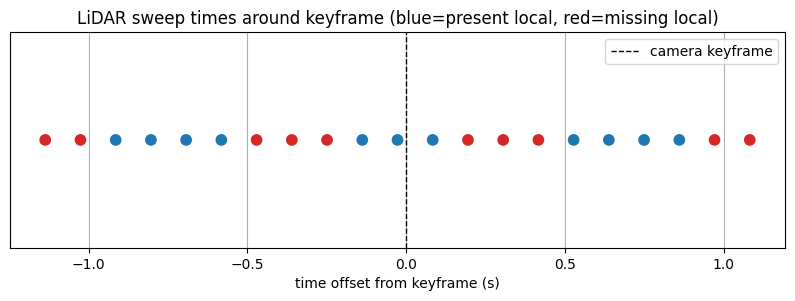

In [17]:
manifest_df = pd.DataFrame(lidar_manifest)
if not manifest_df.empty:
    manifest_df["time_dt"] = manifest_df["time"].apply(_iso_to_dt)
    manifest_df["is_present_local"] = manifest_df["filepath"].apply(lambda s: (LIDAR_DIR / Path(s).name).exists())
    manifest_df = manifest_df.sort_values("time_dt").reset_index(drop=True)

    manifest_df["dt_from_keyframe_s"] = manifest_df["time_dt"].apply(
        lambda t: (t - keyframe_time).total_seconds()
    )

    display_cols = ["time", "dt_from_keyframe_s", "is_present_local", "is_compensated", "filepath"]
    display(manifest_df[display_cols])

    plt.figure(figsize=(10, 2.8))
    colors = manifest_df["is_present_local"].map({True: "tab:blue", False: "tab:red"})
    plt.scatter(manifest_df["dt_from_keyframe_s"], np.zeros(len(manifest_df)), c=colors, s=55)
    plt.axvline(0.0, color="black", linestyle="--", linewidth=1, label="camera keyframe")
    plt.yticks([])
    plt.xlabel("time offset from keyframe (s)")
    plt.title("LiDAR sweep times around keyframe (blue=present local, red=missing local)")
    plt.legend(loc="upper right")
    plt.show()
else:
    print("No lidar manifest found in info.json")

# Assessing frames with no 3D coordinates

- "Objects visible both in the camera image and the LiDAR
point cloud are also labeled with a 9-DOF 3D bounding box,
described by the coordinate of the center of the box, length,
width, height size, and the four quaternion rotation parameters of the cuboid (i.e., qw, qx, qy, and qz)." --- FROM ZOD PAPER

In [18]:
frame_dir = Path("/home/edgelab/zod_dino_data/train2017/000000")

paths = {
    "info": frame_dir / "info.json",
    "metadata": frame_dir / "metadata.json",
    "calibration": frame_dir / "calibration.json",
    "ego_motion": frame_dir / "ego_motion.json",
    "object_detection": frame_dir / "annotations" / "object_detection.json",
}

# 1) Load raw JSON (dict/list)
data = {k: json.loads(p.read_text()) for k, p in paths.items()}
print(data.items())
for k, v in data.items():
    print(f"{k}: {type(v).__name__}")

dict_items([('info', {'id': '000000', 'start_time': '2021-04-19T10:23:09.306996Z', 'end_time': '2021-04-19T10:23:11.526356Z', 'keyframe_time': '2021-04-19T10:23:10.444124Z', 'calibration_path': 'single_frames/000000/calibration.json', 'ego_motion_path': 'single_frames/000000/ego_motion.json', 'metadata_path': 'single_frames/000000/metadata.json', 'oxts_path': 'single_frames/000000/oxts.hdf5', 'vehicle_data_path': None, 'annotations': {'object_detection': {'filepath': 'single_frames/000000/annotations/object_detection.json', 'project': 'object_detection'}, 'lane_markings': {'filepath': 'single_frames/000000/annotations/lane_markings.json', 'project': 'lane_markings'}, 'traffic_signs': {'filepath': 'single_frames/000000/annotations/traffic_signs.json', 'project': 'traffic_signs'}, 'road_condition': {'filepath': 'single_frames/000000/annotations/road_condition.json', 'project': 'road_condition'}}, 'camera_frames': {'front_blur': [{'filepath': 'single_frames/000000/camera_front_blur/000000

In [19]:
# 2) Quick schema inspection (helps before normalization)

print("info keys:", list(data["info"].keys()))
print("metadata keys:", list(data["metadata"].keys()))
print("calibration keys:", list(data["calibration"].keys()))
print("ego_motion keys:", list(data["ego_motion"].keys()))

od = data["object_detection"]
print("object_detection len:", len(od))
print("first annotation top keys:", list(od[0].keys()))
print("first annotation properties keys:", list(od[0]["properties"].keys()))
print("first annotation geometry keys:", list(od[0]["geometry"].keys()))

info keys: ['id', 'start_time', 'end_time', 'keyframe_time', 'calibration_path', 'ego_motion_path', 'metadata_path', 'oxts_path', 'vehicle_data_path', 'annotations', 'camera_frames', 'lidar_frames']
metadata keys: ['frame_id', 'time', 'country_code', 'scraped_weather', 'collection_car', 'road_type', 'road_condition', 'time_of_day', 'num_lane_instances', 'num_vehicles', 'num_vulnerable_vehicles', 'num_pedestrians', 'num_traffic_lights', 'num_traffic_signs', 'longitude', 'latitude', 'solar_angle_elevation']
calibration keys: ['FC']
ego_motion keys: ['poses', 'velocities', 'accelerations', 'angular_rates', 'timestamps', 'origin_lat_lon']
object_detection len: 281
first annotation top keys: ['geometry', 'properties']
first annotation properties keys: ['annotation_uuid', 'class', 'is_for_construction', 'is_on_dynamic_object', 'occlusion_ratio', 'traffic_content_visible', 'type', 'unclear']
first annotation geometry keys: ['coordinates', 'type']


In [20]:
# 3) Normalize object_detection into a tabular form

od_df = pd.DataFrame(od)  # columns: geometry, properties

# Expand properties first so we can filter on the 'class' field inside it
props_df = pd.json_normalize(od_df["properties"])
geom_df = pd.json_normalize(od_df["geometry"]).add_prefix("geometry_")

ann_df = pd.concat([props_df, geom_df], axis=1)

# Filter to pedestrians only (check exact class name with .unique() if unsure)
ann_df = ann_df.loc[ann_df["class"] == "Pedestrian"]

print("ann_df shape:", ann_df.shape)


ann_df shape: (57, 28)


## 9-DOF (3D labels) Coverage Audit 
This cell scans all frames and reports IDs missing 9-DOF 3D boxes.

In [ ]:
# Pedestrian-level 3D coverage scan across the full dataset.
# Goal: identify pedestrian annotations that include full 3D geometry fields
# so we can keep only camera+LiDAR-aligned pedestrian labels.

REQ_PED_3D_KEYS = {
    "location_3d",
    "size_3d_length",
    "size_3d_width",
    "size_3d_height",
    "orientation_3d_qw",
    "orientation_3d_qx",
    "orientation_3d_qy",
    "orientation_3d_qz",
}


def _is_pedestrian_with_full_3d(properties: dict) -> bool:
    """Return True when a pedestrian annotation has all required 3D fields."""
    if not isinstance(properties, dict):
        return False

    # Restrict to pedestrian class only.
    if str(properties.get("class", "")).lower() != "pedestrian":
        return False

    # Require all 3D keys and non-null values.
    return all((k in properties) and (properties[k] is not None) for k in REQ_PED_3D_KEYS)


frame_dirs = [p for p in ORIGINAL_ZOD_ROOT.iterdir() if p.is_dir()]

ped_total_count = 0
ped_with_3d_count = 0
ped_without_3d_count = 0

ped_3d_annotation_uuids: list[str] = []

# Keep one example of a pedestrian annotation missing 3D fields.
example_missing_ped_annotation: dict | None = None
example_missing_frame_id: str | None = None

for frame_dir in frame_dirs:
    od_path = frame_dir / "annotations" / "object_detection.json"
    od = _read_json(od_path)
    if not isinstance(od, list):
        continue

    # Stream through objects: no global giant in-memory structure.
    for ann in od:
        if not isinstance(ann, dict):
            continue
        props = ann.get("properties", {})
        if not isinstance(props, dict):
            continue

        if str(props.get("class", "")).lower() != "pedestrian":
            continue

        ped_total_count += 1
        if _is_pedestrian_with_full_3d(props):
            ped_with_3d_count += 1
            uuid = props.get("annotation_uuid")
            if isinstance(uuid, str) and uuid:
                ped_3d_annotation_uuids.append(uuid)
        else:
            ped_without_3d_count += 1
            if example_missing_ped_annotation is None:
                example_missing_ped_annotation = ann
                example_missing_frame_id = frame_dir.name


ped_with_3d_pct = (100.0 * ped_with_3d_count / ped_total_count) if ped_total_count > 0 else float("nan")
ped_without_3d_frac = (ped_without_3d_count / ped_total_count) if ped_total_count > 0 else float("nan")

print(f"Total pedestrian annotations: {ped_total_count}")
print(f"Pedestrian annotations WITH 3D: {ped_with_3d_count} ({ped_with_3d_pct:.2f}%)")
print(f"Pedestrian annotations WITHOUT 3D: {ped_without_3d_count}")
print(f"Fraction WITHOUT 3D: {ped_without_3d_frac:.6f}")

# Full requested list of UUIDs that have 3D geometry.
print("\nannotation_uuid list for pedestrian annotations WITH 3D:")
print(ped_3d_annotation_uuids)

# Print one concrete example geometry for a pedestrian annotation that is missing 3D fields.
if example_missing_ped_annotation is not None:
    print(f"\nExample pedestrian annotation WITHOUT 3D (frame_id={example_missing_frame_id}):")
    print("geometry:")
    print(json.dumps(example_missing_ped_annotation.get("geometry", {}), indent=2))
    print("properties:")
    print(json.dumps(example_missing_ped_annotation.get("properties", {}), indent=2))
else:
    print("\nNo pedestrian annotations missing 3D fields were found.")
